# import packages

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import stats
import math
from windrose import WindroseAxes

# Loading the data

In [2]:
import pandas as pd

path = "../data/sierraleone-bumbuna.csv"

# If it's a CSV:
df = pd.read_csv(path)
print("Dataset shape (rows, columns):")
print(df.shape)


Dataset shape (rows, columns):
(525600, 19)


# 1. Summary Statistics & Missing-Value Report

In [3]:
print("An overview of the dataset: the first 5 rows")
df.head()

An overview of the dataset: the first 5 rows


,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
0,2021-10-30 00:01,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.1,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN
1,2021-10-30 00:02,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.2,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN
2,2021-10-30 00:03,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.2,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN
3,2021-10-30 00:04,-0.7,0.0,-0.8,0.0,0.0,21.9,99.3,0.0,0.0,0.0,0.0,0.0,1002,0,0.1,22.3,22.6,NaN
4,2021-10-30 00:05,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.3,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN


In [4]:
print("An overview of the dataset: the last 5 rows")
df.tail()

An overview of the dataset: the last 5 rows


,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
525595,2022-10-29 23:56,-1.6,-0.1,-2.9,0.0,0.0,24.0,100.0,0.0,0.0,0.0,0.0,0.0,999,0,0.0,24.2,24.5,NaN
525596,2022-10-29 23:57,-1.7,-0.1,-3.0,0.0,0.0,24.0,100.0,0.0,0.0,0.0,0.0,0.0,999,0,0.0,24.2,24.5,NaN
525597,2022-10-29 23:58,-1.7,-0.1,-3.1,0.0,0.0,24.0,100.0,0.0,0.0,0.0,0.0,0.0,1000,0,0.0,24.1,24.4,NaN
525598,2022-10-29 23:59,-1.7,-0.2,-3.3,0.0,0.0,23.9,100.0,0.0,0.0,0.0,0.0,0.0,1000,0,0.0,24.1,24.4,NaN
525599,2022-10-30 00:00,-1.7,-0.1,-3.4,0.0,0.0,23.9,100.0,0.0,0.0,0.0,0.0,0.0,1000,0,0.0,24.1,24.4,NaN


In [5]:
print("An overview of the dataset: a random sample of 5 rows")
df.sample(5)

An overview of the dataset: a random sample of 5 rows


,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
25539,2021-11-16 17:40,109.4,210.0,76.1,107.8,103.8,31.2,70.7,0.9,1.4,0.6,256.8,10.4,997,0,0.0,36.6,38.7,NaN
365041,2022-07-10 12:02,176.4,0.3,176.3,186.3,182.3,27.1,83.6,0.4,1.1,0.5,293.3,11.7,1002,0,0.0,32.6,33.2,NaN
180333,2022-03-04 05:34,-5.8,-0.3,-5.3,0.0,0.0,22.1,91.1,0.0,0.0,0.0,0.0,0.0,998,0,0.0,21.7,21.9,NaN
7903,2021-11-04 11:44,375.4,1.0,373.5,388.2,378.2,29.8,77.8,0.4,1.1,0.5,292.9,8.3,1001,0,0.0,47.7,47.0,NaN
285673,2022-05-16 09:14,223.0,0.5,223.5,207.4,202.5,28.4,84.0,1.6,2.1,0.4,213.1,10.3,1002,0,0.0,35.0,34.8,NaN


In [6]:
print("An overview of the dataset: the shape of the dataset")
print(df.info())

An overview of the dataset: the shape of the dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525600 entries, 0 to 525599
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Timestamp      525600 non-null  object 
 1   GHI            525600 non-null  float64
 2   DNI            525600 non-null  float64
 3   DHI            525600 non-null  float64
 4   ModA           525600 non-null  float64
 5   ModB           525600 non-null  float64
 6   Tamb           525600 non-null  float64
 7   RH             525600 non-null  float64
 8   WS             525600 non-null  float64
 9   WSgust         525600 non-null  float64
 10  WSstdev        525600 non-null  float64
 11  WD             525600 non-null  float64
 12  WDstdev        525600 non-null  float64
 13  BP             525600 non-null  int64  
 14  Cleaning       525600 non-null  int64  
 15  Precipitation  525600 non-null  float64
 16  TModA          525600

In [7]:
print("The description of the numeric columns:")
print(df.describe())

The description of the numeric columns:
                 GHI            DNI            DHI           ModA  \
count  525600.000000  525600.000000  525600.000000  525600.000000   
mean      201.957515     116.376337     113.720571     206.643095   
std       298.495150     218.652659     158.946032     300.896893   
min       -19.500000      -7.800000     -17.900000       0.000000   
25%        -2.800000      -0.300000      -3.800000       0.000000   
50%         0.300000      -0.100000      -0.100000       3.600000   
75%       362.400000     107.000000     224.700000     359.500000   
max      1499.000000     946.000000     892.000000    1507.000000   

                ModB           Tamb             RH             WS  \
count  525600.000000  525600.000000  525600.000000  525600.000000   
mean      198.114691      26.319394      79.448857       1.146113   
std       288.889073       4.398605      20.520775       1.239248   
min         0.000000      12.300000       9.900000       0.000

In [8]:
print("Check for missing values:")
print(df.isna().sum())

Check for missing values:
Timestamp             0
GHI                   0
DNI                   0
DHI                   0
ModA                  0
ModB                  0
Tamb                  0
RH                    0
WS                    0
WSgust                0
WSstdev               0
WD                    0
WDstdev               0
BP                    0
Cleaning              0
Precipitation         0
TModA                 0
TModB                 0
Comments         525600
dtype: int64


In [9]:
null_percentage = df.isna().mean() * 100
print("Percentage of nulls in each column:")
print(null_percentage)
print("*" * 30)

print("Columns with >5% nulls (percent nulls):")
columns_with_over_5 = null_percentage[null_percentage > 5].sort_values(ascending=False)
if columns_with_over_5.empty:
    print("No columns with >5% nulls")
else:
    print("=============================")
    print(columns_with_over_5)
    print("=============================")

Percentage of nulls in each column:
Timestamp          0.0
GHI                0.0
DNI                0.0
DHI                0.0
ModA               0.0
ModB               0.0
Tamb               0.0
RH                 0.0
WS                 0.0
WSgust             0.0
WSstdev            0.0
WD                 0.0
WDstdev            0.0
BP                 0.0
Cleaning           0.0
Precipitation      0.0
TModA              0.0
TModB              0.0
Comments         100.0
dtype: float64
******************************
Columns with >5% nulls (percent nulls):
Comments    100.0
dtype: float64


In [10]:
# Exact duplicate rows
dup_count = df.duplicated().sum()
print("Duplicate rows:", dup_count)

Duplicate rows: 0


## 1.1 Univariate Analysis

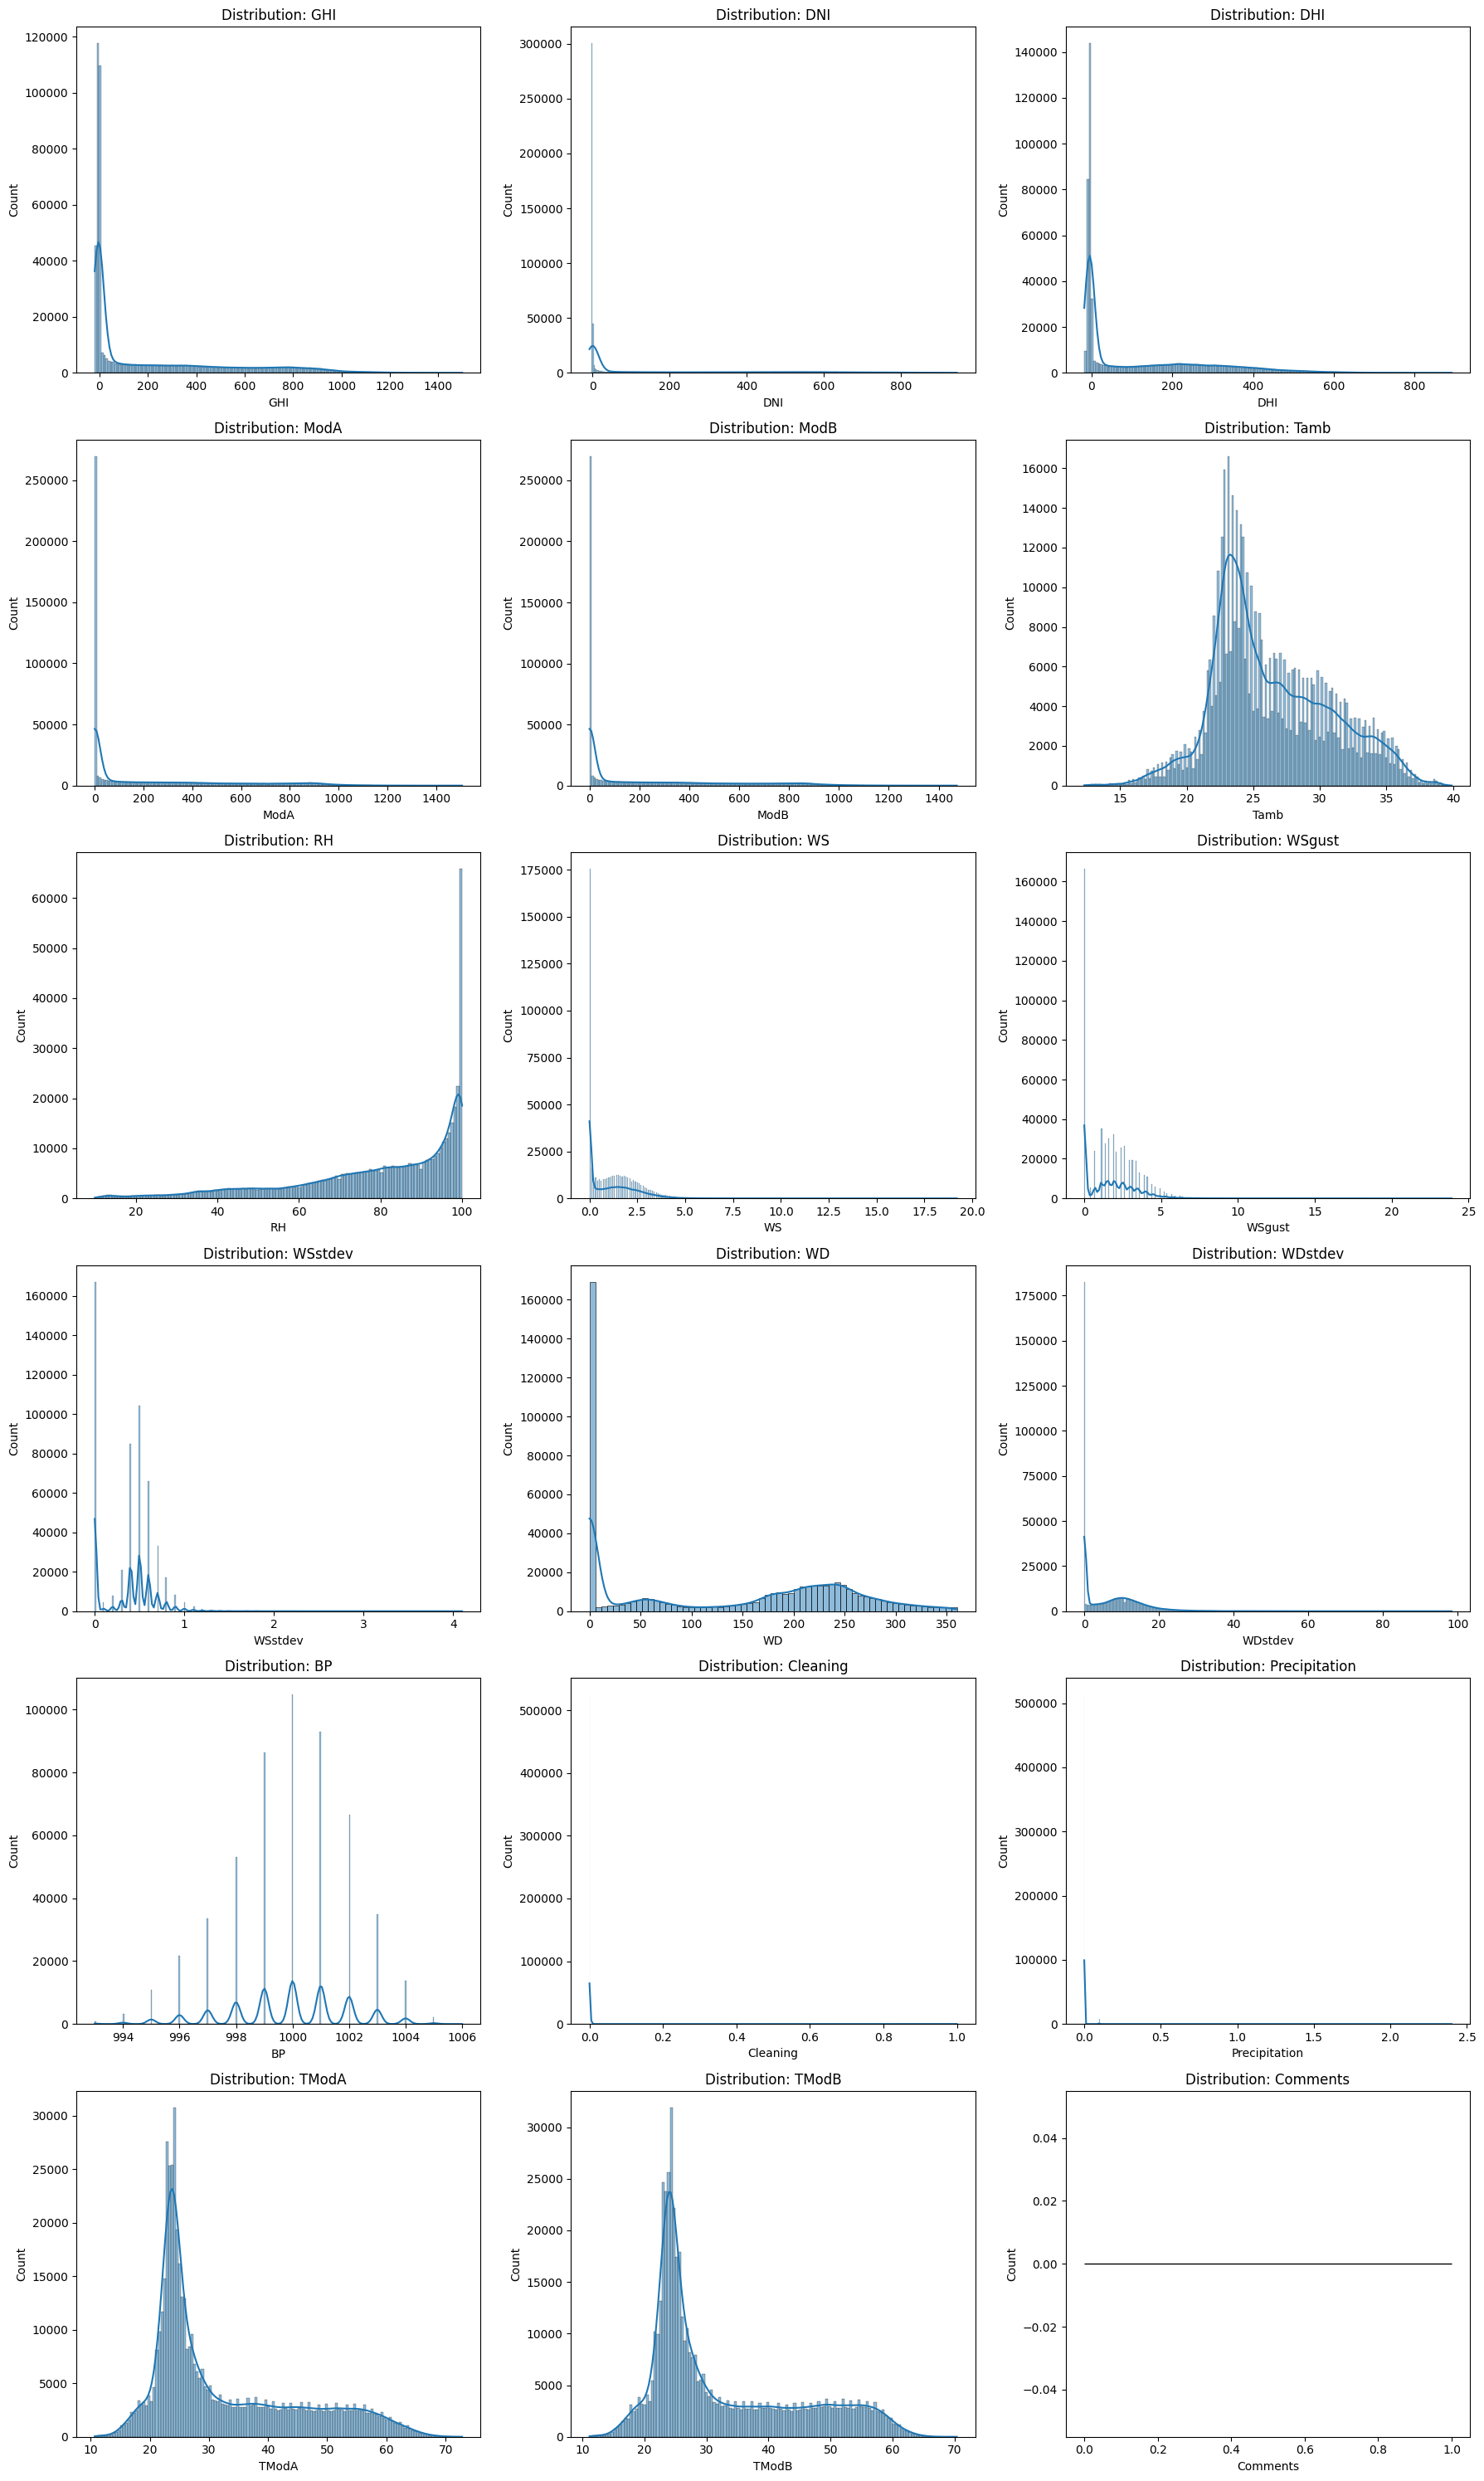

In [11]:
# 1. Get numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# 2. Calculate grid dimensions
n_plots = len(num_cols)
# Determine the number of rows needed (3 plots per row)
n_rows = math.ceil(n_plots / 3) 

# 3. Create a single figure with the calculated grid (3 columns wide)
# figsize=(18, ...) ensures the plots are wide enough to be readable
fig, axes = plt.subplots(n_rows, 3, figsize=(18, 5 * n_rows))

# Flatten the axes array to easily iterate over all subplot locations
axes = axes.flatten()

# 4. Loop and plot each column onto its assigned axis (Histograms: 3 per row)
for i, c in enumerate(num_cols):
    ax = axes[i] # Get the current axis object
    
    # Plot the histogram directly onto the current axis (ax)
    sns.histplot(df[c], kde=True, ax=ax)
    
    ax.set_title(f"Distribution: {c}", fontsize=12)
    ax.set_xlabel(c, fontsize=10)
    ax.set_ylabel("Count", fontsize=10)

# 5. Hide any unused subplots
# This handles cases where n_plots is not a perfect multiple of 3 (e.g., 4, 5, 7, 8 columns)
for j in range(n_plots, n_rows * 3):
    axes[j].axis('off')

plt.tight_layout() # Ensures titles and labels don't overlap
plt.show()

## Univariate Analysis — Interpretation

### Irradiance (GHI, DNI, DHI)
- Strong day/night pattern: many near‑zero (night) records and clear daytime peaks.  
- Daytime peak (hourly_mean) ~670 W/m² (around midday).  
- GHI, DNI, DHI are highly coupled (GHI↔DNI ≈ 0.86, GHI↔DHI ≈ 0.88) — avoid using all three without care (multicollinearity).

### Module readings & module temps (ModA, ModB, TModA, TModB)
- Module power is effectively zero at night; module temperatures rise with sunlight.  
- TModA ↔ TModB correlation ≈ 0.993 — sensors nearly identical; keep one or use their average.  
- Cleaning impact (grouped by Cleaning flag): ModA mean: 189.68 → 273.31 W/m² (≈ +83.6); ModB mean: 181.60 → 277.23 W/m² (≈ +95.6). Verify sample sizes/timing before operational conclusions.

### Wind variables (WS, WSgust, WSstdev, WD, WDstdev)
- Wind speed/gusts are episodic with strong spikes (WSgust present). Inspect timestamps around large gusts to decide if real events or sensor/logging artifacts.  
- Recommendation: either cap/winsorize extreme gusts or encode gust events with binary flags.

### Meteorological controls (Tamb, RH, BP, Precipitation)
- Ambient temperature and RH follow expected diurnal behavior; Tamb peaks in daytime.  
- Precipitation is mostly zero — consider a binary rain flag for event modelling.

### Flags, metadata, and quality indicators
- Comments column is 100% missing — drop it.  
- Exact duplicate rows = 0.  
- Nulls: only Comments shows >5% nulls (100%).


## Box Plots (numeric)

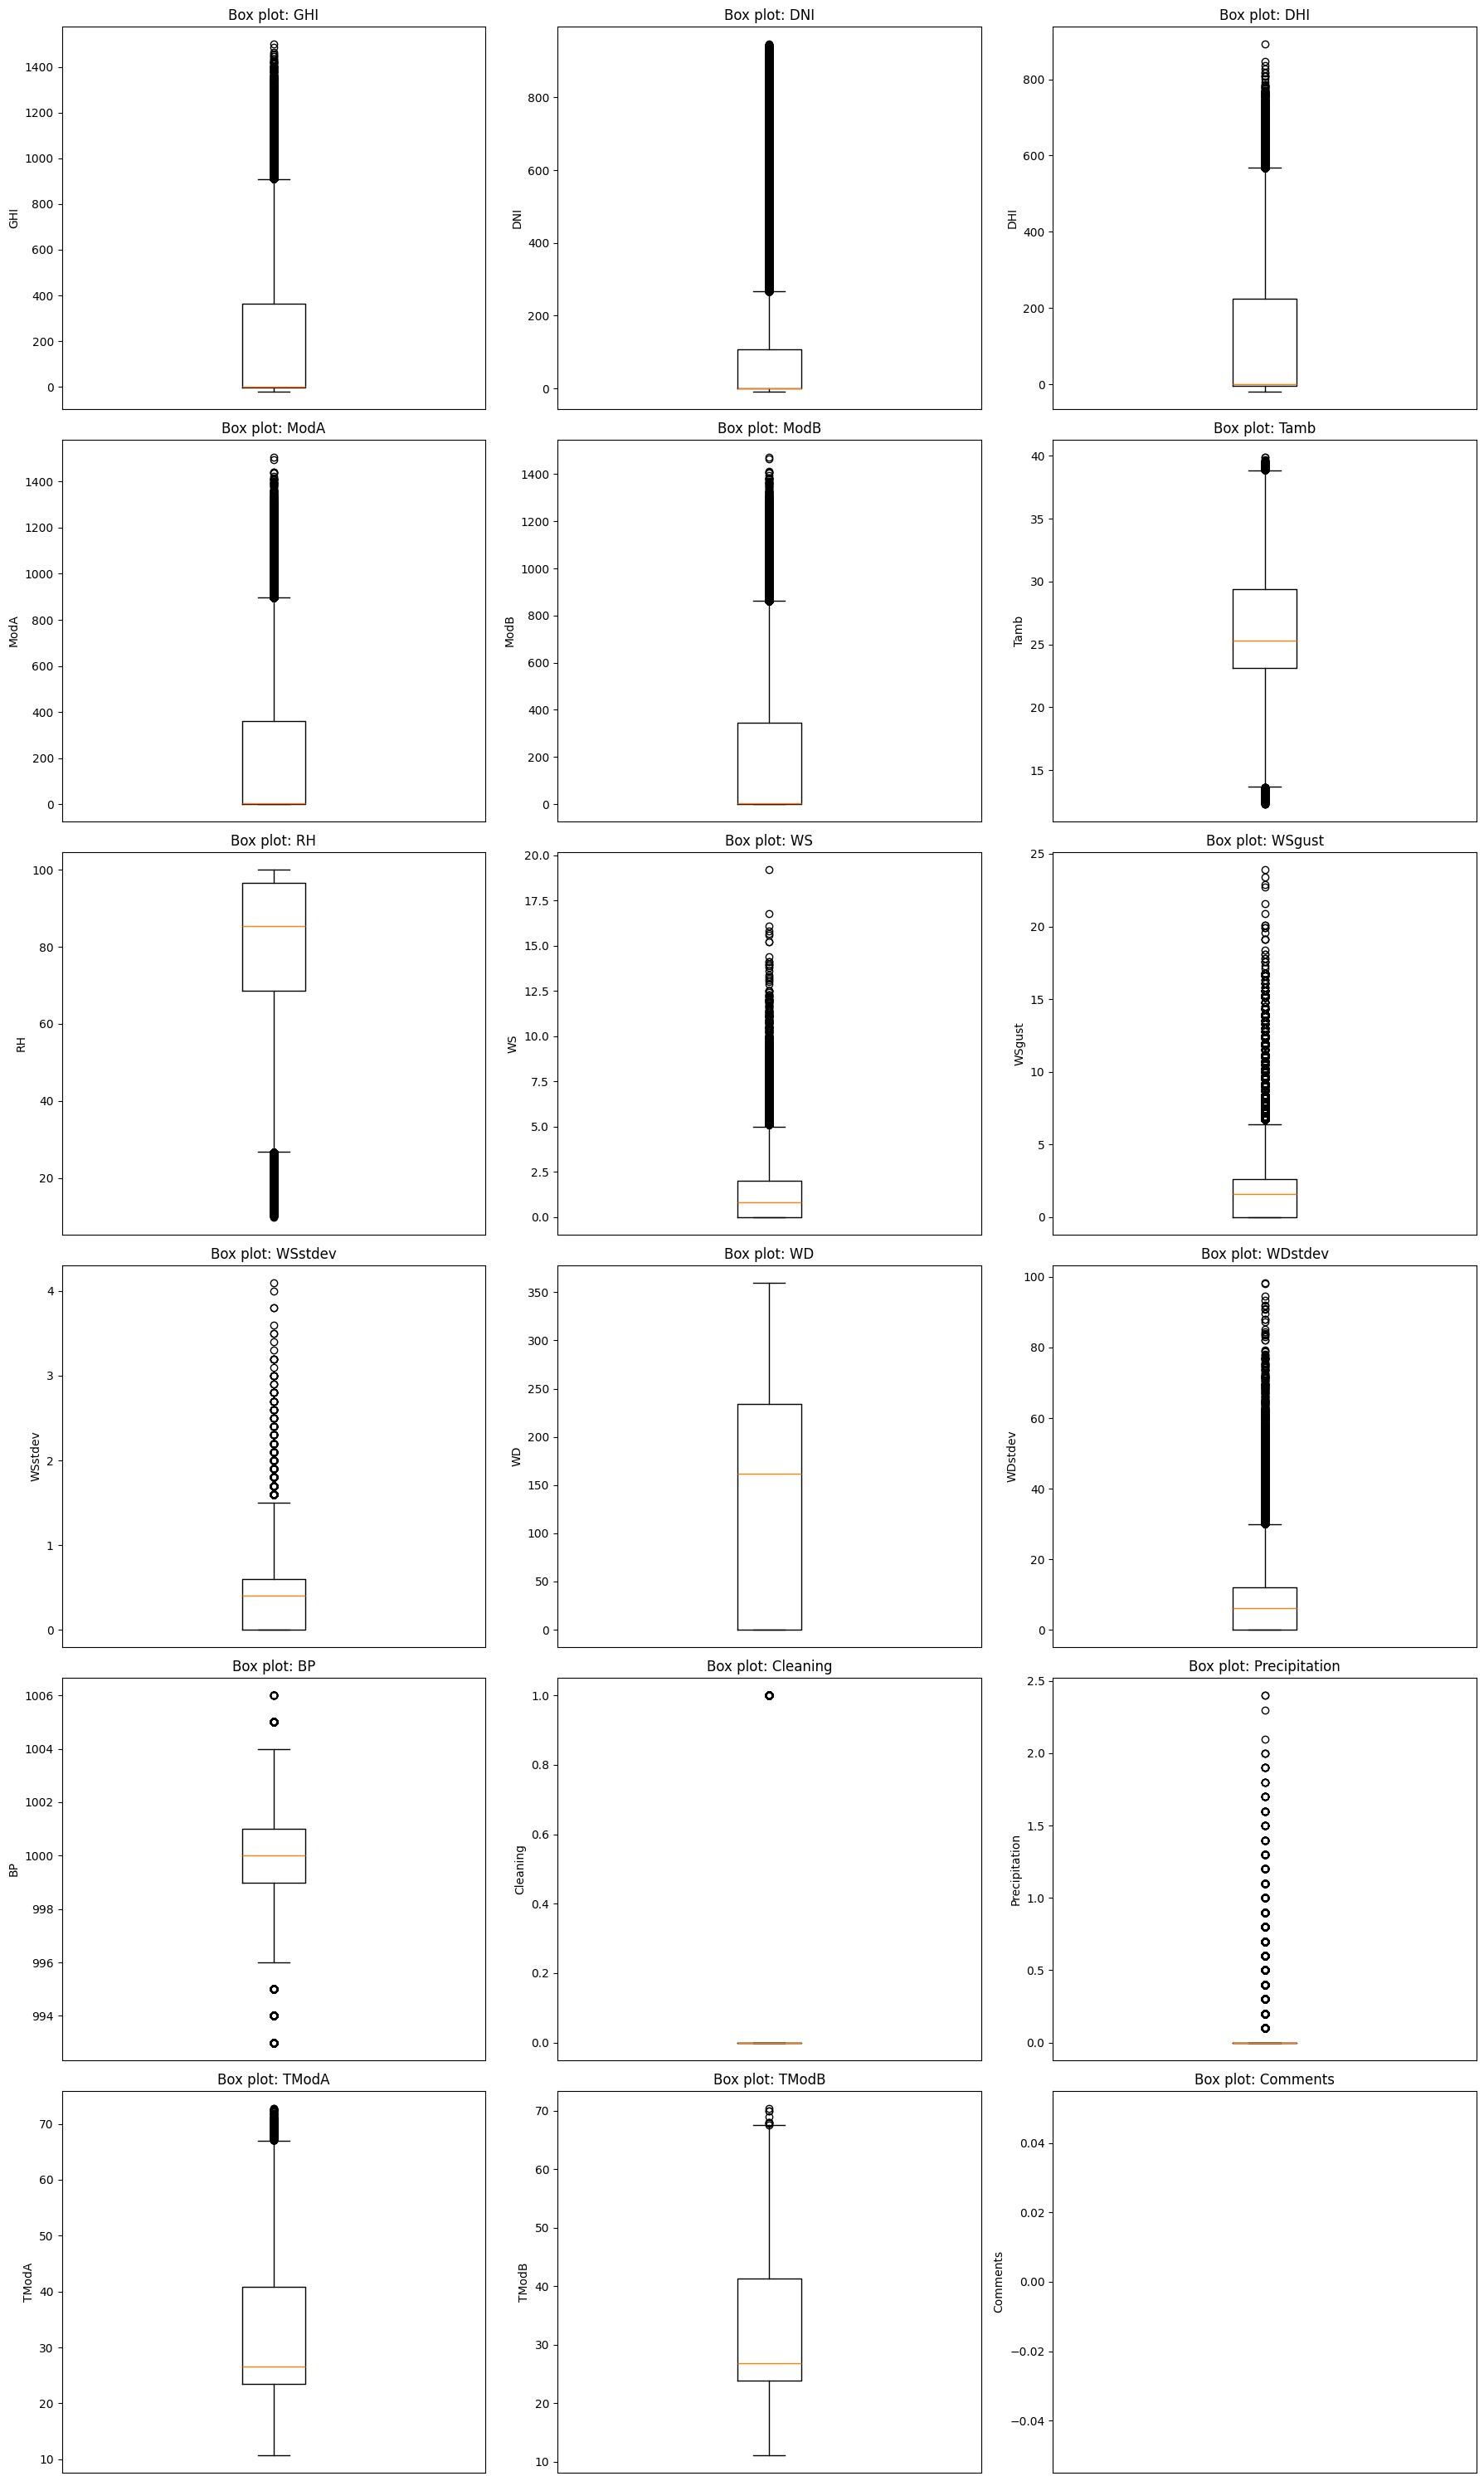

In [12]:
# Create a new figure for the box plots with the same grid dimensions
fig_box, axes_box = plt.subplots(n_rows, 3, figsize=(18, 5 * n_rows))
axes_box = axes_box.flatten()

# Loop and plot each box plot onto its assigned axis
for i, c in enumerate(num_cols):
    ax = axes_box[i]
    
    # Plot the box plot directly onto the current axis (ax)
    ax.boxplot(df[c].dropna(), vert=True)
    
    ax.set_title(f"Box plot: {c}", fontsize=12)
    ax.set_ylabel(c, fontsize=10)
    ax.set_xticks([]) # Remove x-ticks since only one box is plotted per axis

# Hide any unused subplots in the box plot figure
for j in range(n_plots, n_rows * 3):
    axes_box[j].axis('off')

plt.tight_layout()
plt.show()

## Box Plot Analysis – Interpretation

### Irradiance (GHI, DNI, DHI)
- Boxplots show a pronounced day/night split: a large cluster near zero (night) and a long right tail for daytime. Some slightly negative night readings are present.  
- Many points labeled as "outliers" are high daytime values (physical, not necessarily errors).  
- Quantified redundancy: GHI↔DNI ≈ 0.86, GHI↔DHI ≈ 0.88 — using all three without care introduces multicollinearity.  
- Suggestion: restrict boxplots to daytime (Day = GHI > 10) or add a Day/Night facet to interpret daytime distributions separately.

### Module readings & module temps (ModA, ModB, TModA, TModB)
- ModA/ModB are effectively zero at night and show the expected daytime production spread.  
- TModA ↔ TModB correlation ≈ 0.993 — sensors are nearly identical; keep one or use their average.  
- Cleaning impact (group means in df_clean): ModA 189.68 → 273.31 W/m² (+83.6), ModB 181.60 → 277.23 W/m² (+95.6). Verify sample sizes/timing before operational conclusions.  
- Suggestion: compute module summaries only for daytime (GHI > 10) and consider averaging/keeping a single TMod for downstream models.

### Wind variables (WS, WSgust, WSstdev, WD, WDstdev)
- WS and WSgust show heavy upper tails and frequent spikes; WSgust is particularly episodic.  
- Suggestion: inspect timestamps of extreme WSgust values (col = "WSgust") to confirm real events vs sensor/logging artifacts. Options: cap/winsorize extremes or create binary gust-event flags.

### Meteorological controls (Tamb, RH, BP, Precipitation)
- Tamb and RH follow expected diurnal patterns (RH higher at night; Tamb higher by day). Precipitation is mostly zero.  
- No missing values for Tamb/TMod columns in df_clean. BP and Cleaning are stable categorical controls.

### Flags, metadata, and housekeeping
- Comments column is 100% null — drop it (produced an empty boxplot).  
- Exact duplicate rows = 0 (no duplicates remain).  
- Nulls >5%: Comments only (100%).


# 2. Outlier Detection & Basic Cleaning

In [13]:

# 1. Define key columns
key_cols = ["GHI", "DNI", "DHI", "ModA", "ModB", "WS", "WSgust"]

# 2. Handle missing values (impute with median)
for col in key_cols:
    if df[col].isna().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)

# 3. Outlier detection using Z-score (|Z| > 3)
z = np.abs(stats.zscore(df[key_cols], nan_policy="omit"))
outlier_mask = (z > 3).any(axis=1)
print(f"Rows flagged as outliers: {outlier_mask.sum()}")

# 4. Remove outliers
df_clean = df[~outlier_mask].copy()

# 5. Remove exact duplicates
df_clean = df_clean.drop_duplicates()

# 6. Export cleaned DataFrame
df_clean.to_csv("../data/sierraleone_clean.csv", index=False)
print("Cleaned dataset saved to: ../data/sierraleone_clean.csv")

Rows flagged as outliers: 16292
Cleaned dataset saved to: ../data/sierraleone_clean.csv


# 3. Time Series Analysis

C:\Users\dell\AppData\Local\Temp\ipykernel_24920\1544502424.py:17: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


<Figure size 1400x600 with 0 Axes>

c:\BackUp\web-projects\tenx\solar-challenge-week0\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


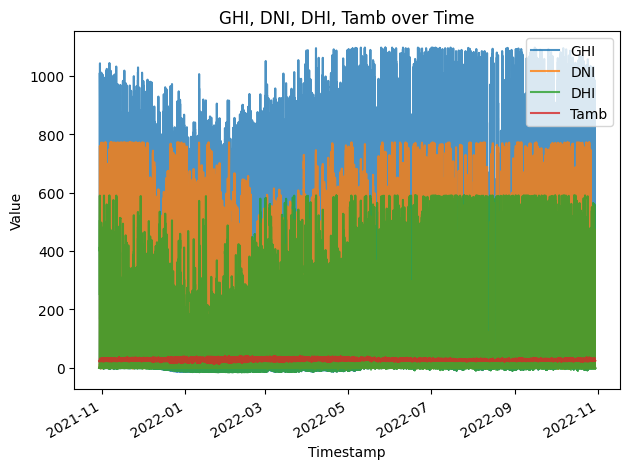

C:\Users\dell\AppData\Local\Temp\ipykernel_24920\1544502424.py:21: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg = df_clean[["GHI", "DNI", "DHI", "Tamb"]].resample("M").mean()


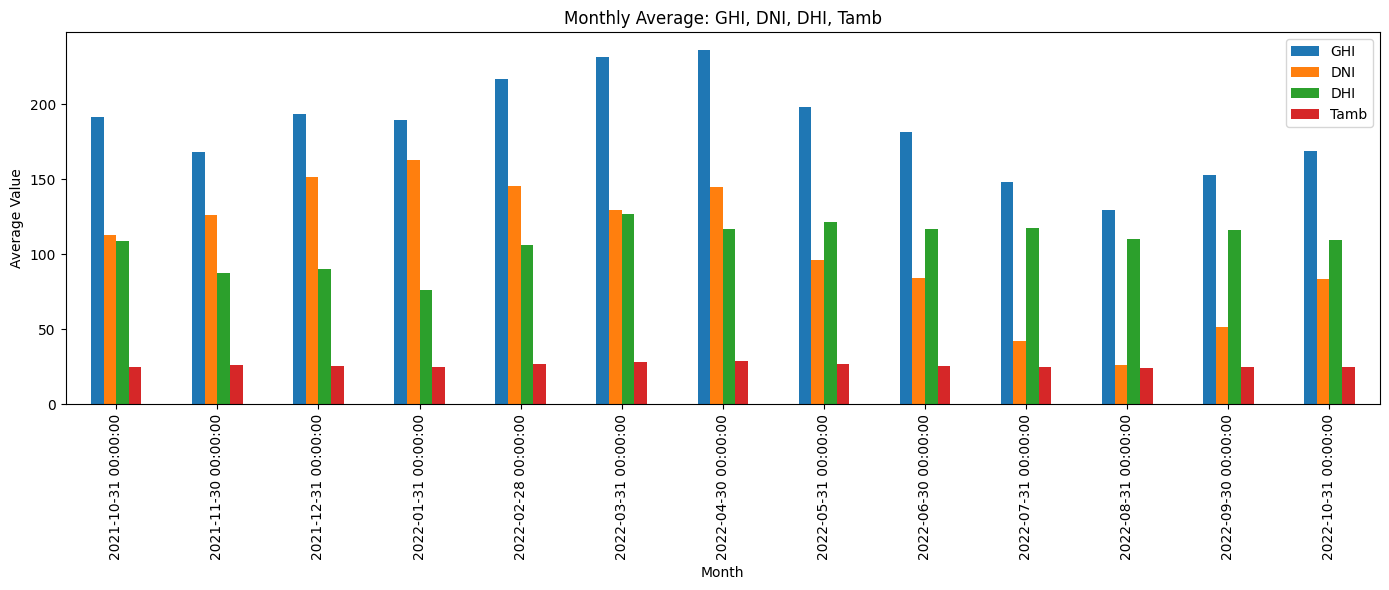

C:\Users\dell\AppData\Local\Temp\ipykernel_24920\1544502424.py:30: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_avg = df_clean[["GHI", "DNI", "DHI", "Tamb"]].resample("H").mean()


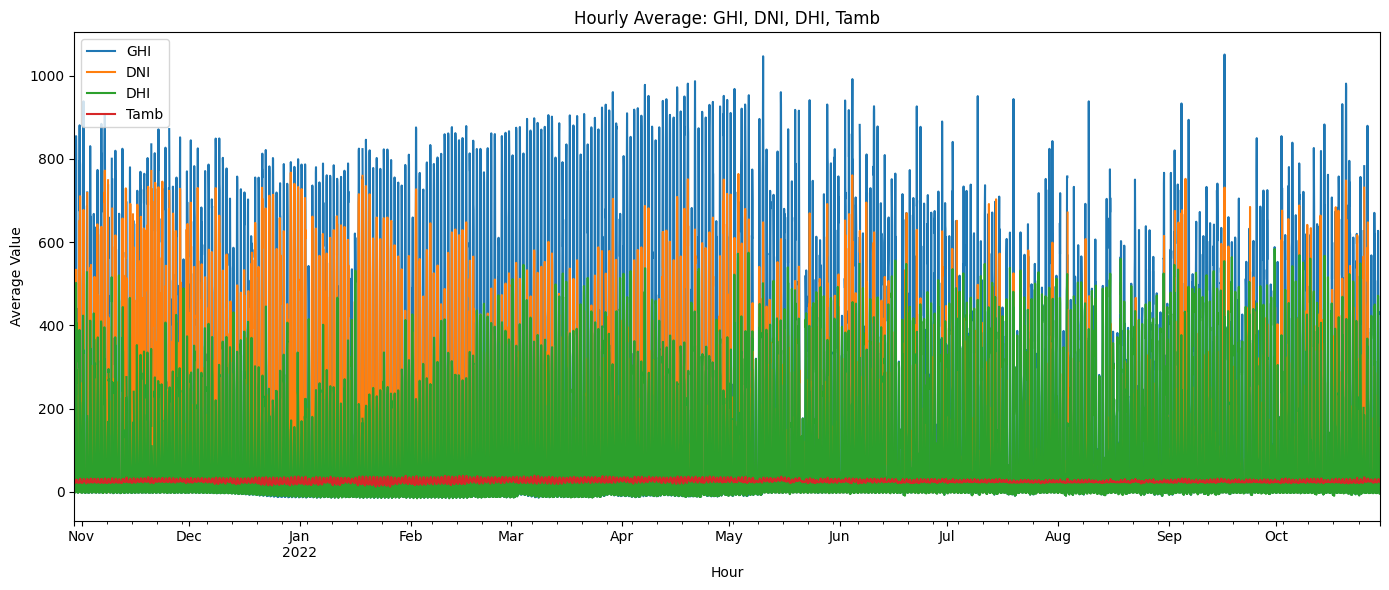

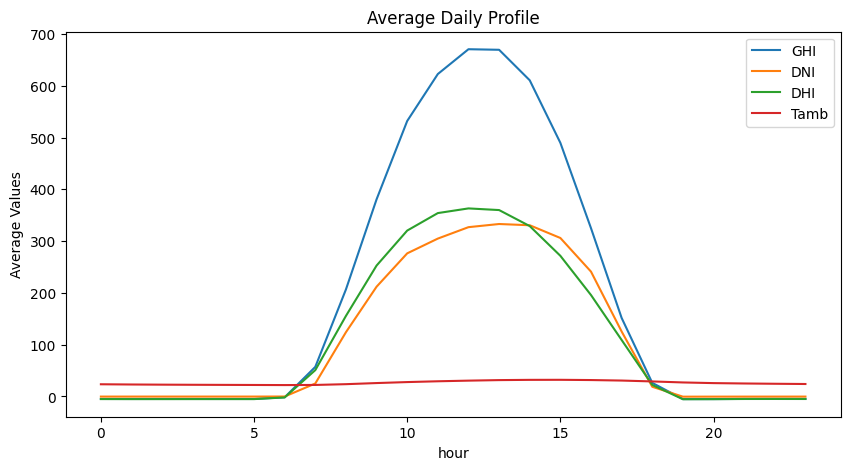

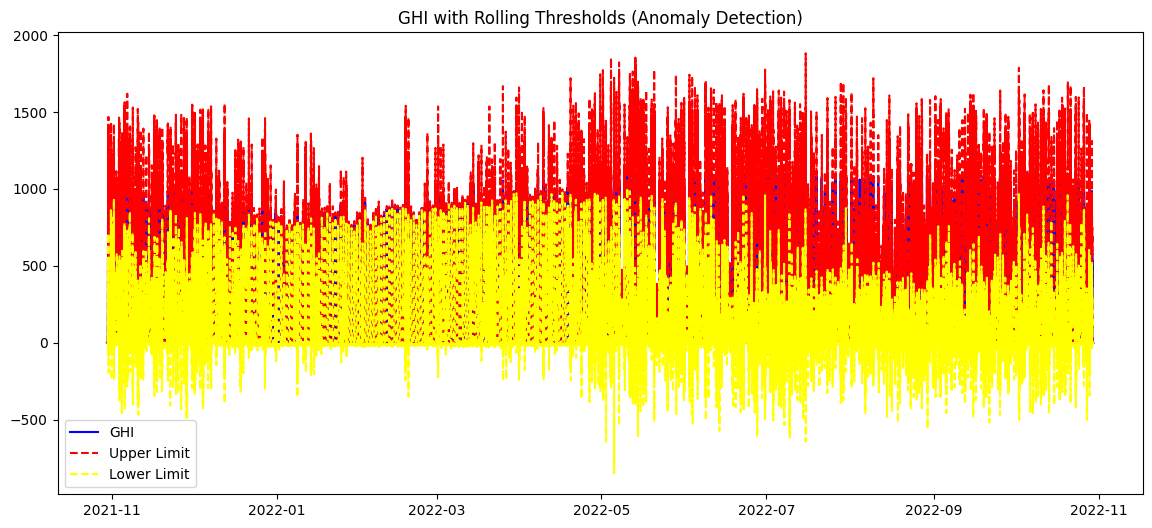

In [14]:
# Load cleaned data
df_clean = pd.read_csv("../data/sierraleone_clean.csv")

# Ensure timestamp is in datetime format
df_clean["Timestamp"] = pd.to_datetime(df_clean["Timestamp"])

# Set timestamp as index for easier plotting
df_clean.set_index("Timestamp", inplace=True)

# Plot line charts for solar irradiance and temperature
plt.figure(figsize=(14, 6))
df_clean[["GHI", "DNI", "DHI", "Tamb"]].plot(alpha=0.8)
plt.title("GHI, DNI, DHI, Tamb over Time")
plt.ylabel("Value")
plt.xlabel("Timestamp")
plt.legend()
plt.tight_layout()
plt.show()

# Monthly average bar chart
monthly_avg = df_clean[["GHI", "DNI", "DHI", "Tamb"]].resample("M").mean()
monthly_avg.plot(kind="bar", figsize=(14, 6))
plt.title("Monthly Average: GHI, DNI, DHI, Tamb")
plt.ylabel("Average Value")
plt.xlabel("Month")
plt.tight_layout()
plt.show()

# Hourly average line chart (diurnal pattern)
hourly_avg = df_clean[["GHI", "DNI", "DHI", "Tamb"]].resample("H").mean()
hourly_avg.plot(figsize=(14, 6))
plt.title("Hourly Average: GHI, DNI, DHI, Tamb")
plt.ylabel("Average Value")
plt.xlabel("Hour")
plt.tight_layout()
plt.show()

# Hourly average line chart() 
df_clean['hour'] = df_clean.index.hour
hourly_mean = df_clean.groupby('hour')[['GHI', 'DNI', 'DHI', 'Tamb']].mean()

hourly_mean.plot(kind='line', figsize=(10, 5), title='Average Daily Profile')
plt.ylabel('Average Values')
plt.show()

#Anomaly visualization
win = 24
mean = df_clean["GHI"].rolling(win).mean()
std = df_clean["GHI"].rolling(win).std()
upper_bar = mean + 3 * std
lower_bar = mean - 3 * std

plt.figure(figsize=(14,6))
plt.plot(df_clean.index, df_clean['GHI'], label='GHI', color='blue')
plt.plot(df_clean.index, upper_bar, color='red', linestyle='--', label='Upper Limit')
plt.plot(df_clean.index, lower_bar, color='yellow', linestyle='--', label='Lower Limit')
plt.title('GHI with Rolling Thresholds (Anomaly Detection)')
plt.legend()
plt.show()

### 3. Time Series Analysis — summary

- Timestamp and data setup
    - Timestamps converted to datetime and set as the index to enable resampling and time-series plotting.
    - Data after cleaning: 509,308 rows (original raw df: 525,600 rows) — 16,292 rows removed (~3.1%).

- Main pattern: day vs night
    - Strong day/night cycle: GHI/DNI/DHI are near zero at night and peak during daytime.
    - Use a simple rule for day/night where useful (example used: GHI > 10 = Day).

- Hourly and monthly behaviour
    - Hourly averages show a repeatable diurnal profile; hourly_mean peaks ≈ 670.5 W/m² (hour 12).
    - Monthly averages are available across 13 months (use month/season features where helpful).

- Data cleaning & anomaly detection
    - Missing values on key columns were median-imputed and outliers removed using Z-score (|Z| > 3) on selected features (GHI, DNI, DHI, ModA, ModB, WS, WSgust).
    - Rolling-window anomaly visualization used a 24-sample window (rolling mean ± 3·std) to flag unusual GHI events.

- Cleaning impact (physical maintenance)
    - Average ModA: before cleaning ≈ 189.68 W/m² → after cleaning ≈ 273.31 W/m² (+≈83.6 W/m², ≈+44%).
    - Average ModB: before cleaning ≈ 181.60 W/m² → after cleaning ≈ 277.23 W/m² (+≈95.6 W/m², ≈+53%).
    - Caveat: verify sample sizes and timestamps for Cleaning = 0 vs 1 before concluding operational impact.

- Quality issues to watch
    - WSgust and some wind columns contain many spikes — inspect timestamps to distinguish real events from sensor noise; consider capping/winsorizing or flagging gust events.
    - Comments column is 100% missing and can be dropped.

- Relationships and redundancy
    - Irradiance channels are highly correlated: GHI↔DNI ≈ 0.86, GHI↔DHI ≈ 0.88 — these channels largely move together and can introduce multicollinearity.
    - Module temperatures are almost identical: TModA↔TModB ≈ 0.993 — keep one sensor or use their average for modelling.
    - Module temps vs irradiance: TModA↔GHI ≈ 0.93, TModB↔GHI ≈ 0.91 — irradiance is the primary driver of module temperature.

# 4. Cleaning Impact


Average Module Irradiance Pre/Post Cleaning
1 = Cleaning Occurred, 0 = No Cleaning
                ModA        ModB
Cleaning                        
0         189.680780  181.598521
1         273.309252  277.231102


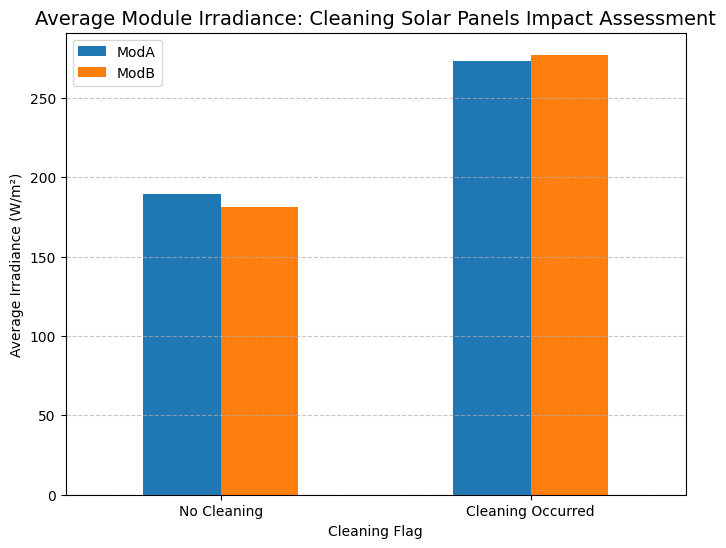

In [15]:
# Cleaning impact assessment
# in this case cleaning means removing dust from solar panels to improve efficiency not data cleaning
# there is a 'Cleaning' column  that exists with 1 for cleaning event and 0 otherwise
cleaning_impact = df_clean.groupby('Cleaning')[['ModA', 'ModB']].mean()

print("\nAverage Module Irradiance Pre/Post Cleaning")
print("1 = Cleaning Occurred, 0 = No Cleaning")
print(cleaning_impact)

# Plotting the impact
plt.figure(figsize=(8, 6))
cleaning_impact.plot(kind='bar', ax=plt.gca())

plt.title('Average Module Irradiance: Cleaning Solar Panels Impact Assessment', fontsize=14)
plt.ylabel('Average Irradiance (W/m²)')
plt.xlabel('Cleaning Flag')
plt.xticks([0, 1], ['No Cleaning', 'Cleaning Occurred'], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Cleaning impact — summary

- Average module irradiance when Cleaning = 0 (no cleaning):  
    - ModA ≈ 189.68 W/m², ModB ≈ 181.60 W/m² → mean ≈ 185.64 W/m².

- Average module irradiance when Cleaning = 1 (cleaning occurred):  
    - ModA ≈ 273.31 W/m², ModB ≈ 277.23 W/m² → mean ≈ 275.27 W/m².

- Observed change: increase ≈ 89.63 W/m² (≈ +48.3% relative increase vs. the pre‑cleaning mean).

- Action items / caveats
    - Verify sample sizes and date ranges for Cleaning = 0 vs 1 to ensure comparable periods (seasonality or different operational windows can bias means).
    - Inspect timestamps around cleaning events for sensor recalibration, metadata changes, or aggregation differences that could inflate post‑cleaning averages.
    - Check distributions (histogram / boxplot) and medians; consider restricting to daytime records (e.g., GHI > 10) to avoid night‑time zeros affecting the comparison.
    - Test statistical significance (e.g., Mann–Whitney U or t‑test after checking assumptions) and control for confounders (month, hour, weather).


# 5. Correlation & Relationship Analysis

### Correlation MAtrix

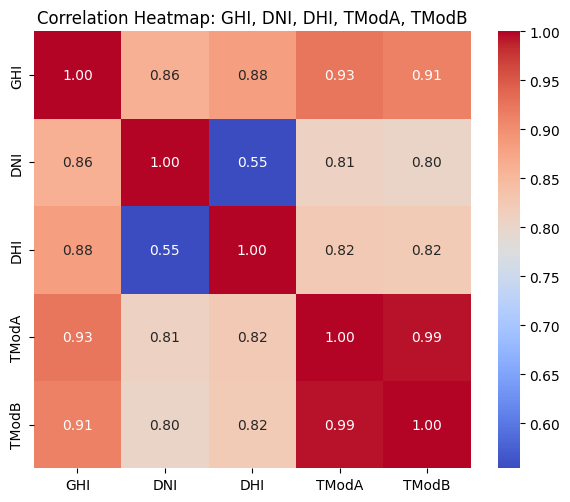

In [16]:
# 1. Correlation heatmap for selected columns
corr_cols = ["GHI", "DNI", "DHI", "TModA", "TModB"]
corr_matrix = df_clean[corr_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Heatmap: GHI, DNI, DHI, TModA, TModB")
plt.tight_layout()
plt.show()



### Wind vs. Solar Irradiance (WS, WSgust, WD vs. GHI)


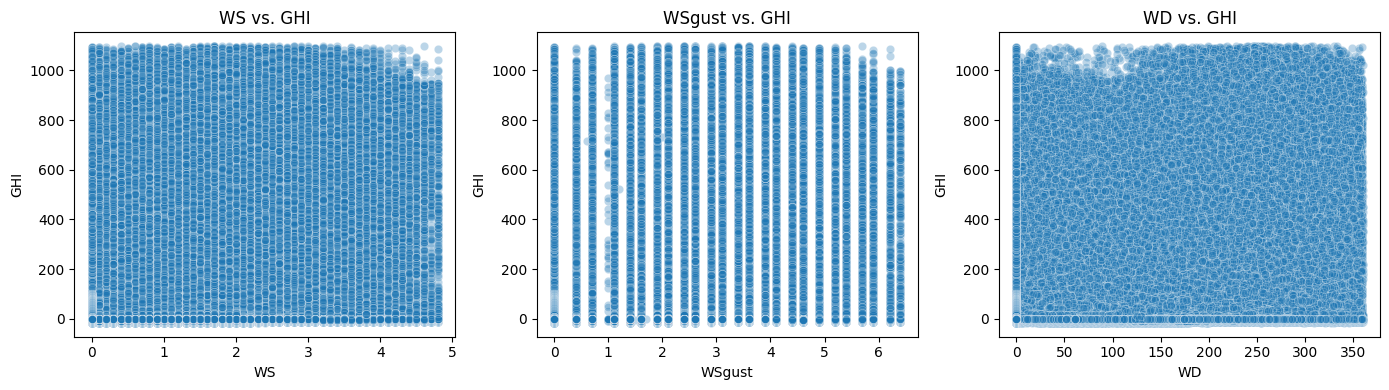

In [17]:
# 2. Scatter plots: wind variables vs. GHI
plt.figure(figsize=(14, 4))
plt.subplot(1, 3, 1)
sns.scatterplot(data=df_clean, x="WS", y="GHI", alpha=0.3)
plt.title("WS vs. GHI")

plt.subplot(1, 3, 2)
sns.scatterplot(data=df_clean, x="WSgust", y="GHI", alpha=0.3)
plt.title("WSgust vs. GHI")

plt.subplot(1, 3, 3)
sns.scatterplot(data=df_clean, x="WD", y="GHI", alpha=0.3)
plt.title("WD vs. GHI")

plt.tight_layout()
plt.show()

### Humidity vs. Temperature/Radiation (RH vs. Tamb or GHI)


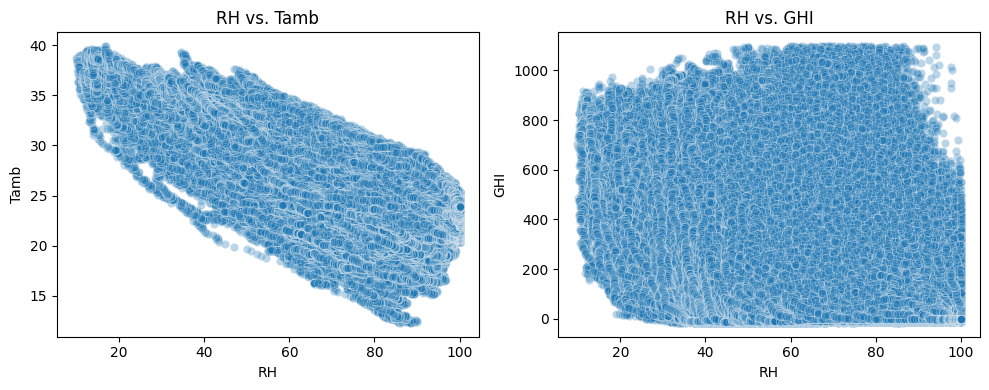

In [18]:
# 3. Scatter plots: RH vs. Tamb and RH vs. GHI
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.scatterplot(data=df_clean, x="RH", y="Tamb", alpha=0.3)
plt.title("RH vs. Tamb")

plt.subplot(1, 2, 2)
sns.scatterplot(data=df_clean, x="RH", y="GHI", alpha=0.3)
plt.title("RH vs. GHI")

plt.tight_layout()
plt.show()

### Correlation & Relationship Analysis — summary

- Key numeric correlations (Pearson)
    - GHI ↔ DNI: 0.86  
    - GHI ↔ DHI: 0.88  
    - DNI ↔ DHI: 0.55  
    - TModA ↔ TModB: 0.99  
    - TModA ↔ GHI: 0.93, TModB ↔ GHI: 0.91  
    - Interpretation: irradiance channels are strongly coupled; module temps are almost identical and strongly driven by irradiance.

- Data quality & housekeeping
    - Raw rows: 525,600 → Cleaned rows: 509,308 (≈3.1% removed).  
    - Exact duplicate rows: 0.  
    - Comments column: 100% null — drop it.  
    - Day/Night is already encoded (Day if GHI > 10) and should be used to separate regimes.

Section summaries

- Correlation matrix
    - Confirms strong couplings among GHI, DNI, DHI and between TMod sensors (risk of multicollinearity).  
    - Recommendation: keep GHI as primary irradiance feature and either drop or transform (PCA/aggregate) DNI/DHI; for module temperature, use one sensor or their average.

- Wind vs. Solar Irradiance (WS, WSgust, WD vs. GHI)
    - Scatter plots show no clear linear relationship between wind metrics and irradiance — wind is largely independent of sunlight level.  
    - WSgust contains episodic spikes (event-driven); inspect timestamps before treating extremes as errors. For modelling, treat wind features as separate drivers or encode gust events, rather than as proxies for irradiance.

- Humidity vs. Temperature/Radiation (RH vs. Tamb or GHI)
    - RH is inversely related to Tamb and generally higher at night (GHI ≈ 0). RH does not replace irradiance as the main driver of module temperature but is a useful control variable (affects module cooling/heating).
    - Use RH and Tamb as controls in models but stratify or adjust for day/night to avoid mixing regimes.


# 6 . Wind & Distribution Analysis


<Figure size 800x800 with 0 Axes>

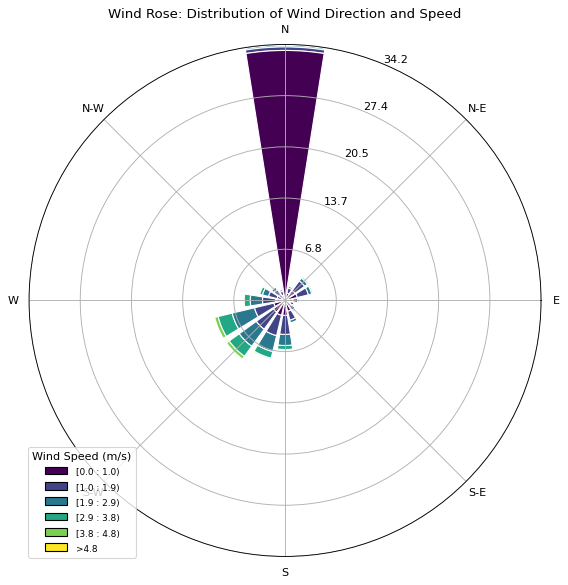

In [19]:
# Wind rose (radial bar plot) for WS and WD
plt.figure(figsize=(8, 8))
ax = WindroseAxes.from_ax()
ax.bar(df_clean['WD'], df_clean['WS'], normed=True, opening=0.8, edgecolor='white')
ax.set_title('Wind Rose: Distribution of Wind Direction and Speed')
ax.set_legend(title='Wind Speed (m/s)')
plt.show()

### Histograms for GHI and WS

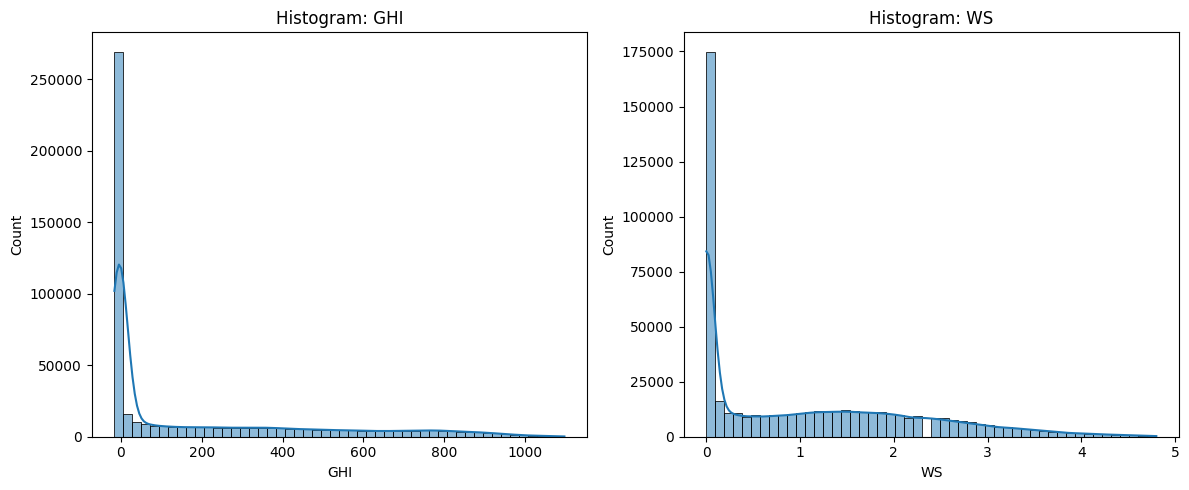

In [20]:
# Histograms for GHI and WS
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_clean["GHI"], bins=50, kde=True)
plt.title("Histogram: GHI")
plt.xlabel("GHI")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
sns.histplot(df_clean["WS"], bins=50, kde=True)
plt.title("Histogram: WS")
plt.xlabel("WS")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

## 6. Wind & Distribution Analysis — Summary

- Dataset / housekeeping
    - Cleaned rows: 509,308 (raw: 525,600) → ~16,292 rows removed (~3.1%).  
    - Exact duplicate rows: 0.  
    - Comments column: 100% null — drop it.

- Wind rose
    - Wind rose plotted (ax available) — directions concentrated around east / southeast; those sectors tend to show stronger wind speeds.
    - Use the wind rose to identify dominant wind sectors for any direction‑dependent analysis (e.g., exposure, soiling transport).

- Wind speed & direction shape
    - WS distribution is heavily right‑skewed: many low/near‑calm values and a thin tail of higher speeds.
    - WSgust is episodic with pronounced spikes while bulk WS remains low (col = "WSgust").

- Gusts, spikes, and quality checks
    - Many large WSgust values may be real meteorological events or sensor/logging artifacts — inspect timestamps around extremes before blanket removal.
    - Recommended workflow:
        - Inspect top N events (e.g., top 0.1% by WSgust) and their timestamps/metadata.
        - If many spikes are non‑physical, cap/winsorize or replace with a percentile threshold (e.g., 99th) or use median imputation for single sensor glitches.
        - Alternatively, create a binary gust flag (e.g., WSgust > p95 or a domain threshold) and model gust events separately.

- Day/night context
    - GHI is near‑zero for most nighttime rows and has a long daytime right tail — day/night structure dominates distributions.
    - Use Day/Night split (Day defined in notebook as GHI > 10 and DayNight column exists) when computing summaries or fitting models to avoid mixing regimes.

# 7 . Temperature Analysis

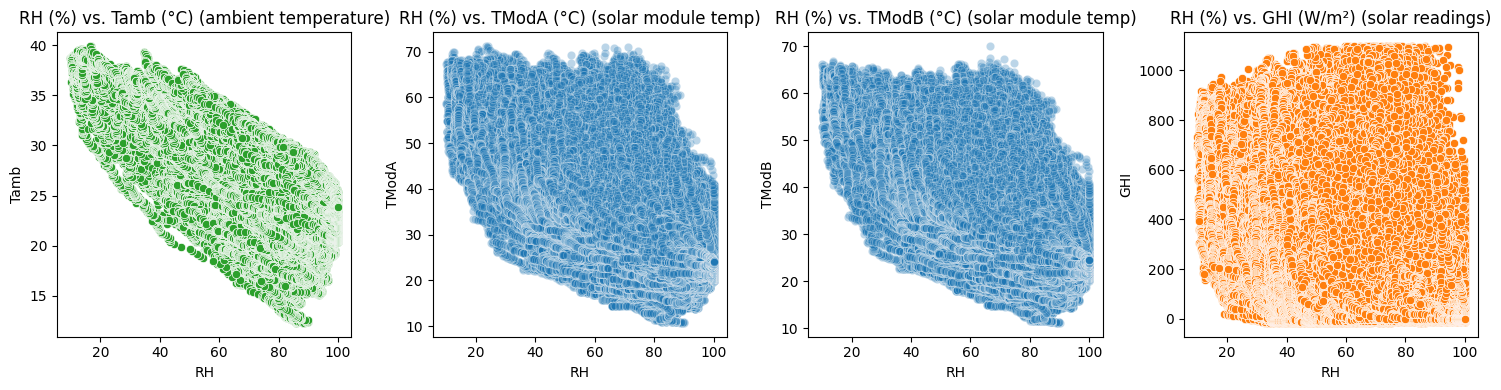

In [21]:
# Scatter plots: RH vs. temperature and solar radiation
plt.figure(figsize=(15, 4))
# Ambient temperature
plt.subplot(1, 4, 1)
sns.scatterplot(data=df_clean, x="RH", y="Tamb",  color="tab:green")
plt.title("RH (%) vs. Tamb (°C) (ambient temperature)")
# Module temperatures
plt.subplot(1, 4, 2)
sns.scatterplot(data=df_clean, x="RH", y="TModA", alpha=0.3)
plt.title("RH (%) vs. TModA (°C) (solar module temp)")

plt.subplot(1, 4, 3)
sns.scatterplot(data=df_clean, x="RH", y="TModB", alpha=0.3)
plt.title("RH (%) vs. TModB (°C) (solar module temp)")
# Solar radiation
plt.subplot(1, 4, 4)
sns.scatterplot(data=df_clean, x="RH", y="GHI", color="tab:orange")
plt.title("RH (%) vs. GHI (W/m²) (solar readings)")

plt.tight_layout()
plt.show()

## 7. Temperature Analysis — Summary

- Key observations
    - RH vs Tamb: clear inverse relationship — higher Tamb (day) → lower RH; lower Tamb (night) → higher RH.
    - Module temps vs drivers:
        - TModA ↔ TModB: ≈ 0.993 (sensors nearly identical).
        - TModA ↔ GHI: ≈ 0.925, TModB ↔ GHI: ≈ 0.914 — module temperatures track solar irradiance strongly.
    - Diurnal / monthly context:
        - Hourly GHI peaks at hour 12 ≈ 670.54 W/m².
        - Hourly Tamb peaks around hour 15 ≈ 32.16 °C.
        - Monthly average Tamb ≈ 24.61 → 28.70 °C (seasonal variation present).
    - Data quality:
        - Analysis run on df_clean (509,308 rows).
        - No missing values for Tamb, TModA, TModB in df_clean.
        - Comments column is 100% null and can be dropped.


# 8 . Bubble Chart

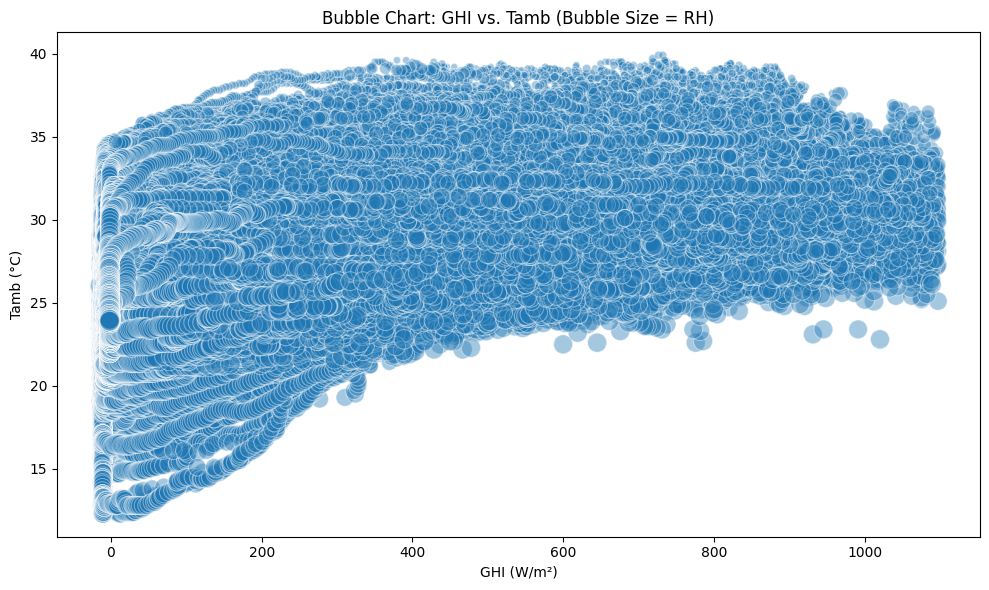

In [22]:

plt.figure(figsize=(10, 6))
bubble_size = df_clean["RH"]  # or use "BP" for bubble size

sns.scatterplot(
    data=df_clean,
    x="GHI",
    y="Tamb",
    size=bubble_size,
    sizes=(20, 200),
    alpha=0.4,
    legend=False
)
plt.title("Bubble Chart: GHI vs. Tamb (Bubble Size = RH)")
plt.xlabel("GHI (W/m²)")
plt.ylabel("Tamb (°C)")
plt.tight_layout()
plt.show()

## 8. Bubble Chart — Summary

- Purpose  
    Visualise the relationship between solar irradiance (GHI) and ambient temperature (Tamb), with bubble size encoding relative humidity (RH).

- Data snapshot  
    - Data used: df_clean (509,308 rows).  
    - RH (bubble size) in this cleaned dataset is tightly distributed near the top of the scale (min ≈ 99.1, max = 100.0, length = 509,308), so size variation is minimal.

- Key observations  
    - Positive relationship: higher GHI generally corresponds to higher Tamb (diurnal heating).  
    - A large cluster of points at GHI ≈ 0 represents nighttime records (DayNight exists: Day if GHI > 10).  
    - RH is slightly larger on many nighttime points, but the RH range is very narrow (≈99.1–100.0) so bubble-size differences are subtle and provide little extra information in this plot.

- Summary  
    - X = GHI (W/m²), Y = Tamb (°C), bubble size = RH (%).  
    - Plot confirms the expected sunlight → warmer air relationship, but bubble size adds limited discrimination because RH is almost constant.


## Multivariate Analysis

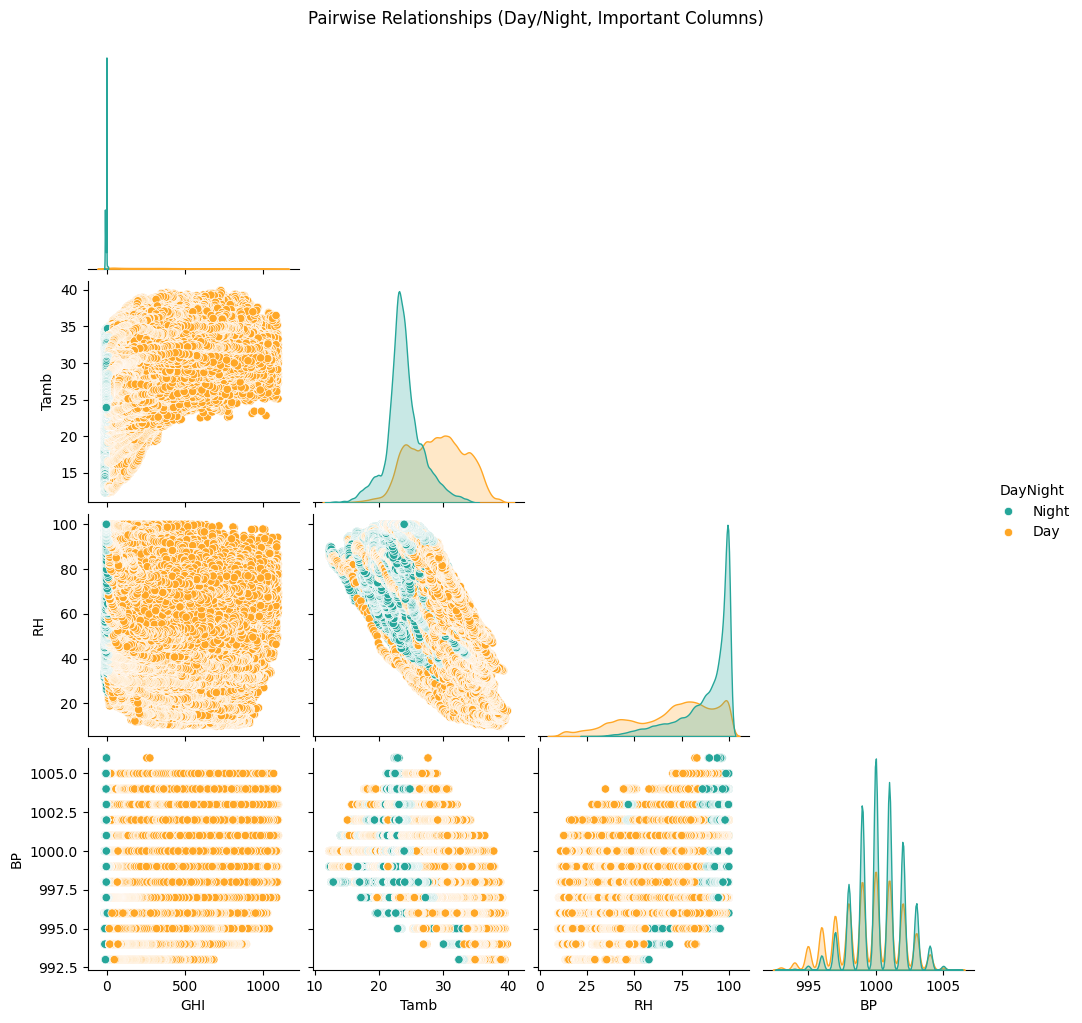

In [23]:
# Pairplot (quick overview)
# Ensure DayNight column exists (e.g., GHI > 10 is day)
df_clean["DayNight"] = np.where(df_clean["GHI"] > 10, "Day", "Night")

# Select important columns only
pairplot_cols = ["GHI", "Tamb", "RH", "BP", "DayNight"]

sns.pairplot(df_clean[pairplot_cols], hue="DayNight", corner=True,
             palette={"Day": "#FFA726", "Night": "#26A69A"})
plt.suptitle("Pairwise Relationships (Day/Night, Important Columns)", y=1.02)
plt.show()


## Multivariate Analysis — Summary

- Data & scope
    - Analysis run on df_clean (509,308 rows). Pairplot used: GHI, Tamb, RH, BP, DayNight (Day if GHI > 10).  
    - Strong day/night separation (cluster at GHI ≈ 0 for night; day/night grouping visually clear).

- Key correlations (Pearson)
    - GHI ↔ DNI: 0.86  
    - GHI ↔ DHI: 0.88  
    - TModA ↔ TModB: 0.99  
    - Module temps ↔ GHI: TModA ≈ 0.93, TModB ≈ 0.91

- Interpretations
    - High multicollinearity among irradiance channels (GHI, DNI, DHI) and between module temperature sensors — many features are redundant. Recommendation: keep GHI as the primary irradiance feature and either drop/transform DNI/DHI (or use PCA/aggregate); for module temperature use one sensor or their average.
    - Pairwise plots (GHI, Tamb, RH) show physically consistent relationships: GHI positively related to Tamb, RH inversely related to Tamb, and clear day/night clusters when colored by DayNight (GHI > 10).
    - Wind variables (WS, WSgust, WD) show weak/unclear relationships with irradiance in scatter plots; WSgust contains episodic spikes — inspect timestamps for gust events, consider capping/winsorizing, or create a gust-event flag.
    - Housekeeping: Comments column is 100% missing and can be dropped.